name: center_node
 - displacement: [0. 0. 0.]
 - location: [0 0 0]
 - num: 0
name: strut_node
 - displacement: [ 0.          0.         -0.01650762]
 - location: [200   0   0]
 - num: 1
name: outer_node
 - displacement: [ 0.          0.         -1.00529324]
 - location: [500   0   0]
 - num: 2
name: strut_node_top
 - displacement: [0. 0. 0.]
 - location: [170.71067812  70.71067812   0.        ]
 - num: 3
name: strut_node_bottom
 - displacement: [0. 0. 0.]
 - location: [170.71067812 -70.71067812   0.        ]
 - num: 4


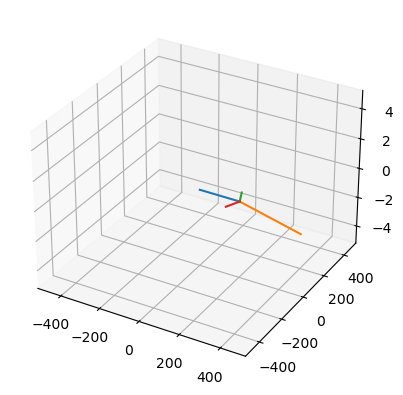

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from Scripts.drone import Drone
from Scripts.beams import BeamType
import Scripts.FEA_3D as FEA_3D

def plot_drone_geometry(drone,q):
    ax = plt.figure().add_subplot(projection='3d')
    ax.set_xlim([-500, 500])
    ax.set_ylim([-500, 500])
    ax.set_zlim([-5, 5])
    drone_geo = drone.beam_system
    node_loc = []
    for i in range(len(drone_geo.nodes)):
        node_loc.append(drone_geo.nodes[i].location)
    #ax.scatter(node_loc[:][0] + drone_geo.x_displacements,
    #           node_loc[:][1] + drone_geo.y_displacements, 
    #           node_loc[:][2] + drone_geo.z_displacements)
    
    for beam in drone_geo.beams:
        '''
        node_0_x = beam.start_node_coords[0]
        node_1_x = beam.end_node_coords[0]
        node_0_y = beam.start_node_coords[1]
        node_1_y = beam.end_node_coords[1]
        node_0_z = beam.start_node_coords[2]
        node_1_z = beam.end_node_coords[2]
        
        X_len = node_1_x - node_0_x
        Y_len = node_1_y - node_0_y
        Z_len = node_1_z - node_0_z

        X = np.empty(q)
        Y = np.empty(q)
        Z = np.empty(q)
        for i in range(q):
            N_X = FEA_3D.shape_function(X_len * i / q, X_len)
            N_Y = FEA_3D.shape_function(Y_len * i / q, Y_len)
            N_Z = FEA_3D.shape_function(Z_len * i / q, Z_len)
            X[i] = node_0_x + N_X[0] * beam.x_displacement[0] + N_X[1] * beam.x_angles[0] + N_X[2] * beam.x_displacement[1] + N_X[3] * beam.x_angles[1]
            Y[i] = node_0_y + N_Y[0] * beam.y_displacement[0] + N_Y[1] * beam.y_angles[0] +  N_Y[2] * beam.y_displacement[1] + N_Y[3] * beam.y_angles[1]
            Z[i] = node_0_z + N_Z[0] * beam.z_displacement[0] + N_Z[1] * beam.z_angles[0] + N_Z[2] * beam.z_displacement[1] + N_Z[3] * beam.z_angles[1]
        '''
        ax.plot([beam.start_node.location[0] + beam.x_displacements_global[0], beam.end_node.location[0] + beam.x_displacements_global[1]],
                [beam.start_node.location[1] + beam.y_displacements_global[0], beam.end_node.location[1] + beam.y_displacements_global[1]],
                [beam.start_node.location[2] + beam.z_displacements_global[0], beam.end_node.location[2] + beam.z_displacements_global[1]])

arm_beam = BeamType("annulus", [25, 20], "Aluminum7075-T6", "arm_beam")
strut_beam = BeamType("annulus", [30, 20], "Aluminum7075-T6", "strut_beam")

d1 = Drone("drone_test",500,200,8,arm_beam,strut_beam)

d1.create_drone_slice_nodes()           # nominal radius | strut rad | number of blades
d1.create_drone_slice_beams(arm_beam,strut_beam) # arm beam | strut beam
d1.beam_system.add_force(np.array([0,0,-1000]),"outer_node")
d1.boundary_conditions_slice()
d1.solve_fea()
plot_drone_geometry(d1,10)

for node_num, node in enumerate(d1.beam_system.nodes):
    print("name: " + str(d1.beam_system.nodes[node_num].name))
    print(" - displacement: " + str(d1.beam_system.nodes[node_num].result_displacement))
    print(" - location: " + str(d1.beam_system.nodes[node_num].location))
    print(" - num: " + str(node_num))



